In [106]:
# All imports needed
import pandas as pd
import numpy as np
import re
import string
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
from classes import Huffman

In [59]:
# Getting Data Ready
path = "sms+spam+collection/SMSSpamCollection"

df = pd.read_csv(path, sep=r"\t", header=None, engine="python")
df = df.rename({0:"Class", 1:"SMS"}, axis=1)

In [60]:
# Function to clean up messages

def clean_str(txt):
    txt = txt.lower()
    # remove leading and trailing whitespace
    txt = txt.strip()
    # removes extra spaces in between words
    txt = re.sub(r'\s+', ' ', txt)

    return txt

# EDA

In [69]:
df['SMS'] = df['SMS'].apply(clean_str)

In [70]:
# Split
spam = df[df['Class'] == 'spam']
ham = df[df['Class'] == 'ham']


In [71]:
# Check the number of spam and ham messages we have to work with
print(f'Spam Count: {spam.shape[0]}\nHam Count: {ham.shape[0]}')

Spam Count: 747
Ham Count: 4827


Very skewed ratio between spam and ham that we have to work with. This will need to be something to consider when creating our model.
* Using metrics like precision, accuracy, and recall might not be best since there is very little spam data. 
* If we were to choose one, we should maybe prioritize false negatives (is spam but marked as non spam) since it would be better to let a spam email pass as opposed to marking an important message as spam and blocking it from going through, so we should use recall

In [72]:
# Check to see if there is an average difference in punctuation/special characters with spam and ham messages

def punctuations(sentence):
    punctuations = re.findall(r'[^A-Za-z0-9\s]+', sentence)
    return punctuations

In [73]:
spam

,Class,SMS
2,spam,free entry in 2 a wkly comp to win fa cup fina...
5,spam,freemsg hey there darling it's been 3 week's n...
8,spam,winner!! as a valued network customer you have...
9,spam,had your mobile 11 months or more? u r entitle...
11,spam,"six chances to win cash! from 100 to 20,000 po..."
...,...,...
5539,spam,want explicit sex in 30 secs? ring 02073162414...
5542,spam,asked 3mobile if 0870 chatlines inclu in free ...
5549,spam,had your contract mobile 11 mnths? latest moto...
5568,spam,reminder from o2: to get 2.50 pounds free call...


In [74]:
ham_punc = ham['SMS'].apply(punctuations)
spam_punc = spam['SMS'].apply(punctuations)

ham_punc_counts = ham_punc.apply(len)
spam_punc_counts = spam_punc.apply(len)

In [75]:
print(f'Ham Punctuation Average: {ham_punc_counts.mean():.2f}\nSpam Punctuation Average: {spam_punc_counts.mean():.2f}')

Ham Punctuation Average: 2.98
Spam Punctuation Average: 5.87


In [76]:
def get_punc(df: pd.DataFrame):

    all_punc = []

    for sent in list(df['SMS']):
        all_punc += punctuations(sent)
    print(len(set(all_punc)))
    print('-------------')

    all_punc = pd.Series(all_punc)

    return all_punc.value_counts()

get_punc(df)


246
-------------


.            5837
,            1947
'            1796
?            1431
!            1121
             ... 
:):)            1
;>              1
...;-)          1
...!鈥┾??〨       1
+).             1
Name: count, Length: 246, dtype: int64

Seems like spam messages tend to have more punctuations/special characters as opposed to ham messages. We can maybe factor this into our model to make a better prediction as to whether or not a message is spam or ham. 

There also doesn't seem to be many region specific symbols, like the pound symbol for example, that are used. We can probably remove or interpret this symbol as a universal currency symbol so as to generalize our model to different regions with different currency. 

I want to now check to see if there is a difference between spam punctuation and ham punctuation. I'm thinking that spam might have more currency symbols. 

In [77]:
get_punc(spam)

77
-------------


.       1496
!        512
,        407
/        326
£        314
        ... 
.£         1
!)         1
****       1
=£         1
+).        1
Name: count, Length: 77, dtype: int64

In [78]:
get_punc(ham)

209
-------------


.            4341
'            1670
,            1540
?            1272
...          1094
             ... 
;>              1
[               1
]               1
...;-)          1
...!鈥┾??〨       1
Name: count, Length: 209, dtype: int64

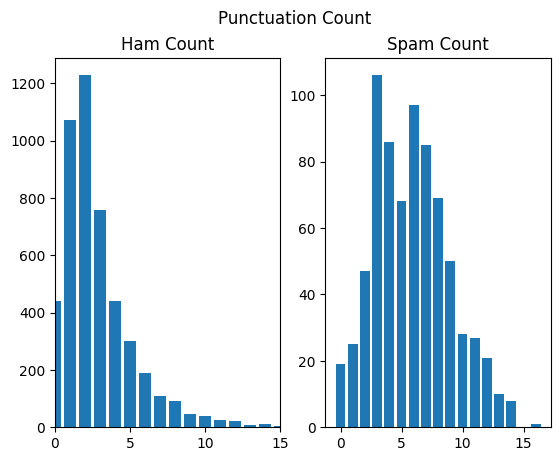

In [79]:
sorted_count_ham = ham_punc_counts.value_counts().sort_index()
sorted_count_spam = spam_punc_counts.value_counts().sort_index()

x_ham = sorted_count_ham.index
y_ham = sorted_count_ham.values

x_spam = sorted_count_spam.index
y_spam = sorted_count_spam.values

fig, axs = plt.subplots(nrows=1, ncols=2)

axs[0].bar(x_ham, y_ham)
axs[1].bar(x_spam, y_spam)

axs[0].set_title('Ham Count')
axs[1].set_title('Spam Count')

axs[0].set_xlim(0, 15)

fig.suptitle("Punctuation Count")

plt.show()

As we could see, the non spam punctuation counter is right skewed. And the spam seems to be normally distributed around the 5-6 mark

## Tokenize SMS

In [108]:
all_words = df['SMS'].str.split(' ').sum()

all_words = pd.Series(all_words)

all_words.value_counts().index



Index(['to', 'i', 'you', 'a', 'the', 'u', 'and', 'is', 'in', 'my',
       ...
       '2.50', 'name,', '£750', '087187272008', 'now1!', 'pity,', 'so...any',
       'suggestions?', 'bitching', 'rofl.'],
      dtype='str', length=13627)

In [109]:
# Convert the value_counts series to a dataframe to be able to use the Huffman class
value_counts_series = all_words.value_counts()

all_words = pd.DataFrame({'Words': value_counts_series.index, 'Counts': value_counts_series})

all_words.reset_index

all_words

,Words,Counts
to,to,2237
i,i,2217
you,you,1921
a,a,1433
the,the,1328
...,...,...
"pity,","pity,",1
so...any,so...any,1
suggestions?,suggestions?,1
bitching,bitching,1


In [110]:
# Test the Huffman class
huff = Huffman(5)

huff.fit(all_words)





KeyError: 'Frequencies'